# Lab 3 Solution Walkthrough: I2S Audio Transmitter and Testbench

**Lecture date:** Friday, October 9, 2026

This notebook walks through the Lab 3 reference solution. The goal is to understand how a precise hardware contract becomes RTL, a self-checking testbench, and a hardware validation plan.

## Lab 3  Suggested Timeline and Due Dates

- **October 7 lecture:** I2S contract, timing.
- **October 9 lecture:** Reference solution, golden vectors, testbench, and hardware bring-up walkthrough.
- **October 12-13:** Senior Trip; no class or lab.
- **October 14 due date:** Simulation materials due.
- **October 20 due date:** Lab 3 hardware validation and student teach-back during the Lab 4 meeting.

Required simulation evidence (30% of your Lab_03 grade): the corrected design passes, and the intentionally broken design fails. Required hardware evidence: BCK, WS, and data are present with the documented timing as shown on an oscilloscope or logic analyzer.

# Designing an I2S Transmitter: The Intuitive Approach

When starting in digital design, jumping straight into flip-flops and state machines can feel overwhelming. For serial protocols like I2S, a traditional "bubble" state diagram is actually the wrong tool because you would have 64 individual states (one for each bit)!

Instead, the most intuitive and systematic way to design serial protocols is using the **"Metronome, Tracker, and Table"** method. 

Imagine a factory assembly line. You need three things to make it run systematically:
1. **The Metronome (Clock Divider):** A signal telling the workers *exactly when* to move. (This is our 3.072 MHz `i2s_bck`).
2. **The Tracker (Frame Counter):** A counter going from `0` to `63` so we know exactly which part of the 64-bit audio frame we are currently building.
3. **The Instruction Table (Output Logic):** A simple cheat sheet that says: *"If the tracker says we are on step 12, put this specific bit on the output line."*

## 1. The Instruction Table (The Secret Sauce)

Instead of complex nested `if/else` statements, we map out exactly what the Word Select (`i2s_ws`) and Data (`i2s_tx_data`) lines should be doing at every single count from `0` to `63`. 

Remember the **1-bit delay** of standard Philips I2S: The MSB (Most Significant Bit) is sent *one clock cycle after* the WS line changes. Because we are sending 24-bit data inside a 32-bit slot, the bottom 8 bits must be padded with zeros.

Here is our master instruction table for the 64 bits:

| Bit Count | Channel | `i2s_ws` | `i2s_tx_data` Output | Math / Note |
| :--- | :--- | :--- | :--- | :--- |
| **0** | **Left** | **0** | `0` (Padding) | WS drops to 0. 1-bit delay starts. |
| **1** | Left | 0 | `left_data[23]` (MSB) | 24 - 1 = 23 |
| **2** | Left | 0 | `left_data[22]` | 24 - 2 = 22 |
| ... | Left | 0 | ... | ... |
| **24** | Left | 0 | `left_data[0]` (LSB) | 24 - 24 = 0 |
| **25 to 31** | Left | 0 | `0` (Padding) | End of Left 32-bit slot |
| **32** | **Right**| **1** | `0` (Padding) | WS rises to 1. 1-bit delay starts. |
| **33** | Right | 1 | `right_data[23]` (MSB) | 56 - 33 = 23 |
| ... | Right | 1 | ... | ... |
| **56** | Right | 1 | `right_data[0]` (LSB) | 56 - 56 = 0 |
| **57 to 63** | Right | 1 | `0` (Padding) | End of Right 32-bit slot |

**The Math Trick:** 
* For the Left channel (counts 1-24), the bit index we want to extract from our 24-bit audio signal is simply `24 - count`. 
* For the Right channel (counts 33-56), the bit index is `56 - count`.

## 2. Separation of Concerns (Modular Design)

In digital design, it is best practice to separate the **Protocol** (the I2S driver) from the **Application** (the Sawtooth generator). 

If we separate them, we can swap out the sawtooth generator later for a microphone filter, a sine wave, or an SDR demodulator *without ever having to touch the complex I2S timing logic again*.

To do this, we use a **Handshake Signal**. The I2S module will pulse a wire called `sample_req` (Sample Request) exactly once per frame to say: *"Hey, I finished sending the last frame, give me the next piece of audio data!"*

---
## How the Sawtooth Generator Works
If you are like me, you probably need to think about how to make a sawtooth generator to test the I2S block.  

### 1. Two's Complement: The 24-bit Limits
In a 24-bit signed system, the highest bit (Bit 23) determines the sign: `0` means positive, and `1` means negative.

Here are the four most important numbers to know in a 24-bit system:
* **`24'h000000` (Zero):** All bits are 0. Value = $0$.
* **`24'h7FFFFF` (Maximum Positive):** The sign bit is 0, and all other bits are 1. Value = $+8,388,607$.
* **`24'h800000` (Maximum Negative):** The sign bit is 1, and all other bits are 0. Value = $-8,388,608$.
* **`24'hFFFFFF` (Minus One):** All bits are 1. Value = $-1$.
* 
Remember this three-bit two's complement diagram from Digital Logic?  With 24 bits, it is similar; the wrap around just happens less frequently, and the circle is enormous.
  
                         000 =  0
                      ↗           ↘
                001 = +1       111 = -1
                  ↑                 ↓
            010 = +2               110 = -2
                  ↑                 ↓
                011 = +3       101 = -3
                      ↘           ↙
                         100 = -4
                       │
                       │
                       └──────→ Wrap around happens here!
  
  
## 2. How the Sawtooth is Born (The Wrap Around or Odometer Effect)
We set our starting point to the absolute bottom of our limit:
`SAW_START = 24'h800000` ($-8,388,608$)

Every time the I2S module asks for a new sample, we add our step:
`SAW_STEP = 24'h010000` ($+65,536$)

If we keep adding $+65,536$, the number climbs up through the negative numbers, crosses zero, and keeps climbing through the positive numbers.

**But what happens when we hit the Maximum Positive limit (`24'h7FFFFF`)?**
If we add `0x010000` to a number near `0x7FFFFF`, the binary math literally overflows the 24-bit register. The 24th bit turns into a `1`, which instantly turns the number into a **large negative number**.

Just like a mechanical car odometer flipping from `999,999` back to `000,000`, our 24-bit register flips from its maximum positive value straight back to `24'h800000` (its maximum negative value). **This sudden drop creates the sharp vertical cliff of the sawtooth wave!**

---

## 3. Python Simulation
Because Python automatically handles huge numbers, it doesn't naturally "overflow" at 24 bits like an FPGA does. In the Python code below, we simulate the FPGA's 24-bit register limit to show you exactly what the hardware is doing.

In [9]:
%%capture
%pip install matplotlib

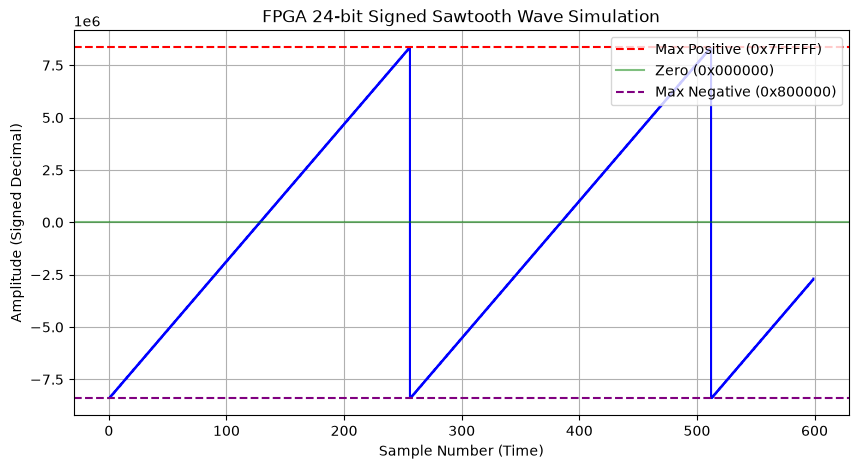

In [10]:
import matplotlib.pyplot as plt

# --- FPGA Parameters ---
SAW_START = 0x800000  # Start at the maximum negative binary value
SAW_STEP  = 0x010000  # The amount we add every sample

# --- 24-bit Math Limits ---
MAX_POS = 8388607     # 0x7FFFFF
MAX_NEG = -8388608    # 0x800000

# Helper function to mimic how the FPGA interprets 24-bit Two's Complement
def to_signed_24bit(val):
    # Keep only the bottom 24 bits (simulating a 24-bit hardware register)
    val = val & 0xFFFFFF 
    # If the 24th bit (sign bit) is 1, it's a negative number
    if val >= 0x800000:
        return val - 0x1000000
    return val

# --- Generate the Wave ---
y_values = []
current_val = SAW_START

# Let's simulate exactly 600 audio samples
for _ in range(600):
    # 1. Convert hardware binary to a signed integer for plotting
    y_values.append(to_signed_24bit(current_val))
    
    # 2. Add the step (The FPGA does this every sample request)
    current_val += SAW_STEP

# --- Plotting the Wave ---
plt.figure(figsize=(10, 5))
plt.plot(y_values, color='b', drawstyle='steps-post')

# Draw lines showing the 24-bit limits
plt.axhline(MAX_POS, color='r', linestyle='--', label="Max Positive (0x7FFFFF)")
plt.axhline(0, color='g', linestyle='-', alpha=0.5, label="Zero (0x000000)")
plt.axhline(MAX_NEG, color='purple', linestyle='--', label="Max Negative (0x800000)")

plt.title("FPGA 24-bit Signed Sawtooth Wave Simulation")
plt.xlabel("Sample Number (Time)")
plt.ylabel("Amplitude (Signed Decimal)")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

## 3. The SystemVerilog Code
Below is the complete implementation, split into three clear modules.
### Module 1: The Sawtooth Generator
This module does absolutely nothing regarding I2S timing. It just waits for the sample_req pulse and increments its output wave.

```systemverilog

// ============================================================================
// Module: sawtooth_gen
// Description: Generates a 24-bit sawtooth wave. Updates only when requested.
// ============================================================================
module sawtooth_gen #(
    parameter logic [23:0] SAW_START = 24'h800000,
    parameter logic [23:0] SAW_STEP  = 24'h010000
) (
    input  logic clk_30m,
    input  logic reset_n,
    input  logic sample_req,     // Handshake: Pulses high to ask for next value
    output logic [23:0] out_data // The 24-bit audio/SDR data
);

    always_ff @(posedge clk_30m or negedge reset_n) begin
        if (!reset_n) begin
            out_data <= SAW_START;
            
        end else if (sample_req == 1'b1) begin
            // Only step the wave forward when the I2S module asks for it!
            out_data <= out_data + SAW_STEP;
            
        end
    end

endmodule
```

### Module 2: The I2S Master Transmitter
This module translates our "Instruction Table" directly into code. Notice how decoupling the timing (the Metronome) from the logic makes it incredibly easy to read.

```systemverilog
// ============================================================================
// Module: i2s_master_tx
// Description: Standard Philips I2S Master. Reads parallel data and 
//              serializes it with correct BCK, WS, and 1-bit delay timing.
// ============================================================================
module i2s_master_tx #(
    parameter integer BCK_HALF_DIV = 5
) (
    input  logic clk_30m,
    input  logic reset_n,
    
    // Application Data Interface
    input  logic [23:0] left_data,   // Data for the Left channel
    input  logic [23:0] right_data,  // Data for the Right channel
    output logic sample_req,         // Handshake: Pulses high when frame ends
    
    // I2S Hardware Pins
    output logic i2s_bck,
    output logic i2s_ws,
    output logic i2s_tx_data
);

    // 1. The Metronome
    logic [2:0] bck_divider; // We need three bits to count to 5.
    
    // 2. The Tracker
    logic [5:0] bit_cnt;     // We need 6 bits to count to 64.

    always_ff @(posedge clk_30m or negedge reset_n) begin
        if (!reset_n) begin  // Reset everything to 0.
            bck_divider <= '0;
            bit_cnt     <= '0;
            i2s_bck     <= 1'b0;
            i2s_ws      <= 1'b0;
            i2s_tx_data <= 1'b0;
            sample_req  <= 1'b0;
            
        end else begin
            // Default state for our handshake pulse. It automatically
            // drops back to 0 unless explicitly set to 1 below.
            sample_req <= 1'b0;

            // --- THE METRONOME ---
            if (bck_divider == BCK_HALF_DIV - 1) begin
                bck_divider <= '0;
                i2s_bck     <= ~i2s_bck; // Toggle the Bit Clock

                // --- ACTION ON THE FALLING EDGE OF BCK ---
                // I2S spec says master MUST change data/WS on the falling edge.
                if (i2s_bck == 1'b1) begin
                    
                    // --- THE TRACKER ---
                    if (bit_cnt == 6'd63) begin
                        bit_cnt    <= 6'd0;
                        sample_req <= 1'b1; // Ask external module for new data!
                    end else begin
                        bit_cnt    <= bit_cnt + 1'b1;
                    end

                    // --- THE INSTRUCTION TABLE: WS ---
                    if (bit_cnt >= 6'd0 && bit_cnt <= 6'd31) begin
                        i2s_ws <= 1'b0; // Left Channel
                    end else begin
                        i2s_ws <= 1'b1; // Right Channel
                    end

                    // --- THE INSTRUCTION TABLE: DATA ---
                    if (bit_cnt == 6'd0 || bit_cnt == 6'd32) begin
                        i2s_tx_data <= 1'b0; // 1-bit delay padding
                        
                    end else if (bit_cnt >= 6'd1 && bit_cnt <= 6'd24) begin
                        i2s_tx_data <= left_data[24 - bit_cnt]; // Shift Left Data
                        
                    end else if (bit_cnt >= 6'd33 && bit_cnt <= 6'd56) begin
                        i2s_tx_data <= right_data[56 - bit_cnt]; // Shift Right Data
                        
                    end else begin
                        i2s_tx_data <= 1'b0; // Bottom 8 bits padding
                    end

                end
            end else begin
                bck_divider <= bck_divider + 1'b1;
            end
        end
    end

endmodule
```

### Module 3: The Top-Level Wrapper (The "Breadboard")
Finally, we need a module that wires the Sawtooth Generator's outputs to the I2S Driver's inputs. 

```systemverilog
// ============================================================================
// Module: top_i2s_demo
// Description: Top-level module wiring the Sawtooth generator to the I2S driver.
// ============================================================================
module top_i2s_demo (
    input  logic clk_30m,
    input  logic reset_n,
    
    // I2S Hardware Pins going to the RP2040
    output logic i2s_bck,
    output logic i2s_ws,
    output logic i2s_tx_data
);

    // Wires (logic signals) to connect the two modules together
    logic [23:0] audio_signal;
    logic        get_next_sample;

    // Instantiate Module 1: The Generator
    sawtooth_gen #(
        .SAW_START(24'h800000),
        .SAW_STEP(24'h010000)
    ) my_sawtooth (
        .clk_30m(clk_30m),
        .reset_n(reset_n),
        .sample_req(get_next_sample), // Input from I2S
        .out_data(audio_signal)       // Output to I2S
    );

    // Instantiate Module 2: The I2S Transmitter
    i2s_master_tx #(
        .BCK_HALF_DIV(5)
    ) my_i2s (
        .clk_30m(clk_30m),
        .reset_n(reset_n),
        .left_data(audio_signal),     // Play sawtooth on Left channel
        .right_data(audio_signal),    // Play sawtooth on Right channel
        .sample_req(get_next_sample), // Output asking for new data
        .i2s_bck(i2s_bck),
        .i2s_ws(i2s_ws),
        .i2s_tx_data(i2s_tx_data)
    );

endmodule
```

### How the Handshake Works
Look closely at the `get_next_sample` wire (driven by `sample_req`). 
When the I2S tracker hits `bit_cnt == 63`, it pulses this wire high. Because both modules share the same `clk_30m` clock, the Sawtooth module sees the high pulse on the very next system clock cycle and instantly updates its `out_data`. 

By the time the I2S module actually needs to shift the MSB out at `bit_cnt == 1` (several System Clock cycles later), the new audio data has been sitting securely on the `audio_signal` wire, ready to be read. This is exactly how complex digital subsystems safely synchronize and pass data to one another!

# Generating "Golden Vectors"
Often, you need to generate inputs and outputs, and Python is a good way to do that.  Here is a Python script that generates test vectors so your test bench can test the sawtooth wave. We need to remember what the sawtooth wave looks like in order to produce test vectors from it.  Here is a Python script that generates the golden vectors.

In [2]:
from pathlib import Path

FRAME_COUNT = 3
SAW_START = 0x800000
SAW_STEP = 0x010000
SAMPLE_MASK = (1 << 24) - 1

def slot_word(sample):
    return (sample & SAMPLE_MASK) << 8

def frame_lines(frame_index, sample):
    word = slot_word(sample)
    bits = f"{word:032b}"
    return [
        f"frame={frame_index} sample=0x{sample:06x} ws=0 bits={bits}",
        f"frame={frame_index} sample=0x{sample:06x} ws=1 bits={bits}",
    ]

text_lines = [
    "# Each frame contains one WS=0 left slot followed by one WS=1 right slot.",
    "# Each slot is the exact 32 bits sampled on BCK rising edges.",
]
words = []
sample = SAW_START
for frame_index in range(FRAME_COUNT):
    text_lines.extend(frame_lines(frame_index, sample))
    word = slot_word(sample)
    words.extend((f"{word:08x}", f"{word:08x}"))
    sample = (sample + SAW_STEP) & SAMPLE_MASK

print("\n".join(text_lines))
print("\nExpected memory words:")
print("\n".join(words))

# Each frame contains one WS=0 left slot followed by one WS=1 right slot.
# Each slot is the exact 32 bits sampled on BCK rising edges.
frame=0 sample=0x800000 ws=0 bits=10000000000000000000000000000000
frame=0 sample=0x800000 ws=1 bits=10000000000000000000000000000000
frame=1 sample=0x810000 ws=0 bits=10000001000000000000000000000000
frame=1 sample=0x810000 ws=1 bits=10000001000000000000000000000000
frame=2 sample=0x820000 ws=0 bits=10000010000000000000000000000000
frame=2 sample=0x820000 ws=1 bits=10000010000000000000000000000000

Expected memory words:
80000000
80000000
81000000
81000000
82000000
82000000


## The I2S Self-Checking Testbench

A testbench is essentially a piece of software that pretends to be the external hardware your FPGA is talking to. In this case, **our testbench acts exactly like the Raspberry Pi Pico receiver.**

Instead of relying on human eyes to stare at waveforms in GTKWave, an industry-standard testbench is **self-checking**. It reads a file of "Golden Vectors" (the mathematically perfect expected results), reads the serial data coming out of your simulated FPGA, rebuilds the 32-bit words, and compares them. If they match, it prints `PASS`. If anything is wrong—even shifted by a single bit—it immediately stops and prints `FAIL`.

## 2. The Testbench Code
Save this as `i2s_tb.sv`. Look specifically at the `always @(posedge i2s_bck)` block. It implements the exact 5 steps described in the notebook!

### Here is the Testbench:

```systemverilog
`timescale 1ns/1ps

module i2s_tb;

    // --------------------------------------------------------
    // 1. GENERATE THE MASTER CLOCK
    // --------------------------------------------------------
    logic clk_30m = 0;
    always #16 clk_30m = ~clk_30m; // ~30.72 MHz

    // Hardware Wires
    logic reset_n;
    logic i2s_bck;
    logic i2s_ws;
    logic i2s_tx_data;

    // --------------------------------------------------------
    // 2. INSTANTIATE THE DEVICE UNDER TEST (DUT)
    // --------------------------------------------------------
    top_i2s_demo dut (
        .clk_30m(clk_30m),
        .reset_n(reset_n),
        .i2s_bck(i2s_bck),
        .i2s_ws(i2s_ws),
        .i2s_tx_data(i2s_tx_data)
    );

    // --------------------------------------------------------
    // 3. LOAD THE GOLDEN VECTORS
    // --------------------------------------------------------
    logic [31:0] expected_words [0:5];
    initial $readmemh("expected_words.mem", expected_words);

    // --------------------------------------------------------
    // 4. THE RECEIVER EMULATOR (Self-Checking Logic)
    // --------------------------------------------------------
    integer words_checked = 0;
    logic [31:0] shift_reg = 0;
    
    logic prev_ws = 1'b0;
    integer bit_idx = 0;
    logic active_slot = 1'b0;

    initial begin
        // Reset the system
        reset_n = 0;
        #100;
        reset_n = 1;
        
        // Timeout Watchdog: If the test gets stuck, kill it
        #500000;
        $display("FAIL: Simulation Timeout");
        $finish;
    end

    // The Pico Receiver samples data ONLY on the RISING edge of BCK
    always @(posedge i2s_bck) begin
        if (reset_n) begin
            
            // I2S RULE: WS changes one clock cycle BEFORE the MSB.
            // If we detect WS has flipped, the current bit on the wire 
            // is the 1-bit dummy delay. We ignore it and start reading next cycle.
            if (i2s_ws !== prev_ws) begin
                prev_ws = i2s_ws;
                bit_idx = 0;
                active_slot = 1'b1;
            end 
            // If we are currently reading a slot...
            else if (active_slot && bit_idx < 32) begin
                
                // Shift the data bit into our 32-bit register (MSB first)
                shift_reg = {shift_reg[30:0], i2s_tx_data};
                bit_idx++;

                // Once we have collected all 32 bits, run the checks!
                if (bit_idx == 32) begin
                    
                    // Check #1: Did the Word Select (WS) line match what we expect?
                    // Even slots (0, 2, 4) should be Left (0), Odd should be Right (1)
                    logic expected_ws = (words_checked % 2 != 0); 
                    if (i2s_ws !== expected_ws) begin
                        $display("FAIL: WS mismatch at word %0d. Expected %b, got %b", 
                                 words_checked, expected_ws, i2s_ws);
                        $finish;
                    end

                    // Check #2: Does the data perfectly match the Python Golden Vector?
                    if (shift_reg !== expected_words[words_checked]) begin
                        $display("FAIL: Data mismatch at word %0d. Expected 0x%08x, got 0x%08x", 
                                 words_checked, expected_words[words_checked], shift_reg);
                        $finish;
                    end else begin
                        $display("Word %0d matched: 0x%08x (WS=%b)", 
                                 words_checked, shift_reg, i2s_ws);
                    end

                    words_checked++;
                    active_slot = 1'b0; // Sleep until the next WS edge happens

                    // Stop with success after 6 checked slots
                    if (words_checked == 6) begin
                        $display("PASS");
                        $finish;
                    end
                end
            end
        end
    end

endmodule
```

### Understanding the SystemVerilog

#### 1. Timescale and Clock Generation
```systemverilog
`timescale 1ns/1ps

logic clk_30m = 0;
always #16 clk_30m = ~clk_30m; // ~30.72 MHz
```
* **`` `timescale 1ns/1ps ``**: Tells the simulator that `#1` means 1 nanosecond, and calculations are accurate down to 1 picosecond.
* **`always #16 ...`**: An infinite loop in simulation. Every 16 nanoseconds, `clk_30m` inverts (`~`). A full clock cycle takes $16\,\text{ns} + 16\,\text{ns} = 32\,\text{ns}$.
  $$\text{Frequency} = \frac{1}{32 \times 10^{-9}\,\text{s}} = 31.25\,\text{MHz}$$
  *(The real frequency is 30.720 MHz.  This module has only one clock, and for testing it is not important if the clock is a tad fast.)*

---

#### 2. Instantiating the Device Under Test (DUT)
```systemverilog
top_i2s_demo dut (
    .clk_30m(clk_30m),
    .reset_n(reset_n),
    .i2s_bck(i2s_bck),
    .i2s_ws(i2s_ws),
    .i2s_tx_data(i2s_tx_data)
);
```
* This drops your actual hardware design (`top_i2s_demo`) into the simulation.
* It feeds your clock and reset into the DUT.
* It receives three standard I2S output signals:
  * **`i2s_bck` (Bit Clock):** Ticks once for every single bit of audio transferred.
  * **`i2s_ws` (Word Select / LRCLK):** Indicates which channel is playing (`0` = Left, `1` = Right).
  * **`i2s_tx_data`:** The serial stream carrying the audio bits one by one.

---

#### 3. Loading the Golden Reference
```systemverilog
logic [31:0] expected_words [0:5];
initial $readmemh("expected_words.mem", expected_words);
```
* **`expected_words`**: An array holding six 32-bit words.
* **`$readmemh(...)`**: A built-in SystemVerilog function that reads a text file (`expected_words.mem`) filled with hexadecimal numbers and loads them into the array. This is the "golden reference" the DUT is supposed to produce.

---

#### 4. Reset & Watchdog Timer
```systemverilog
initial begin
    // Reset the system
    reset_n = 0;
    #100;
    reset_n = 1;
    
    // Timeout Watchdog: If the test gets stuck, kill it
    #500000;
    $display("FAIL: Simulation Timeout");
    $finish;
end
```
* **`initial` block**: Executes once starting at simulation time $t = 0$.
* **`reset_n = 0; #100; reset_n = 1;`**: Drives active-low reset low for 100 ns to initialize the DUT, then releases it.
* **Watchdog (`#500000;`)**: If something breaks (e.g., your DUT freezes or enters an infinite loop), simulation would run forever. After $500{,}000\,\text{ns}$, it forces the simulation to exit (`$finish`) with a failure message.

---

#### 5. The Emulated I2S Receiver (Self-Checking Logic)
This is the core of the testbench. It triggers on every rising edge of the DUT's bit clock (`always @(posedge i2s_bck)`).

##### A. Handling the I2S 1-Clock Delay
```systemverilog
if (i2s_ws !== prev_ws) begin
    prev_ws = i2s_ws;
    bit_idx = 0;
    active_slot = 1'b1;
end
```
* The official **Philips I2S standard** has a unique quirk: the `WS` signal changes **one clock cycle before** the most significant bit (MSB) arrives.
* When this code notices `i2s_ws` change, it knows: *"The current bit is just a 1-bit padding/delay cycle. Reset our bit counter to 0, and start collecting the real payload on the next clock."*

##### B. Deserializing Data (Bit to Word)
```systemverilog
else if (active_slot && bit_idx < 32) begin
    shift_reg = {shift_reg[30:0], i2s_tx_data};
    bit_idx++;
```
* **`{shift_reg[30:0], i2s_tx_data}`**: This is a bit concatenation that creates a **shift register**.
* It takes the existing 31 lowest bits, shifts them to the left by 1 position, and appends the new bit arriving on `i2s_tx_data` at the bottom.
* Because I2S sends bits **MSB-first**, doing this 32 times perfectly reconstructs the original 32-bit audio word.

##### C. Checking the Results
```systemverilog
if (bit_idx == 32) begin
    // Check #1: Did WS alternate correctly?
    logic expected_ws = (words_checked % 2 != 0); 
    if (i2s_ws !== expected_ws) begin
        $display("FAIL: WS mismatch...");
        $finish;
    end

    // Check #2: Does the data match the golden reference?
    if (shift_reg !== expected_words[words_checked]) begin
        $display("FAIL: Data mismatch...");
        $finish;
    end else begin
        $display("Word %0d matched...", ...);
    end
```
Once all 32 bits of a word have arrived:
1. **Word Select Check**: Even words (`0, 2, 4`) must have `WS = 0` (Left Channel); odd words (`1, 3, 5`) must have `WS = 1` (Right Channel).
2. **Data Check**: Compares the assembled 32-bit `shift_reg` against `expected_words[words_checked]`. If even one bit differs, it terminates immediately with `FAIL`.

##### D. Passing the Test
```systemverilog
    words_checked++;
    active_slot = 1'b0;

    if (words_checked == 6) begin
        $display("PASS");
        $finish;
    end
```
* After successfully validating 6 audio words (3 Left/Right pairs), the testbench prints `"PASS"` and gracefully ends the simulation with `$finish`.

---

### Helpful SystemVerilog Syntax for Beginners

| Syntax | Meaning |
| :--- | :--- |
| `!==` | **Case inequality operator:** Compares two signals including `x` (unknown) and `z` (high impedance) states, unlike standard `!=`. |
| `initial` | Code runs **once** at the start of the simulation (used only in testbenches, not synthesizable hardware). |
| `always @(...)` | Runs **every time** the specified event occurs (here, whenever `i2s_bck` transitions from `0` to `1`). |
| `{a, b}` | **Concatenation operator:** Glues bits together into a wider bus. |
| `$finish` | Built-in simulator command that cleanly terminates the run. |

## 3. How the Testbench Proves the Contract (Explanation)

Notice how this testbench doesn't care *how* you wrote your RTL. It only cares about the physical I2S protocol contract on the pins. Here is how it fulfills the 5 steps from the notebook:

1. **It observes each `posedge i2s_bck`**: The checker is inside an `always @(posedge i2s_bck)` block. It is completely blind to what happens on the falling edge, just like a real receiver.
2. **It checks the expected WS level**: At the exact moment it captures the 32nd bit, it evaluates `expected_ws = (words_checked % 2 != 0)` and verifies `i2s_ws` is currently at that level.
3. **It shifts in exactly 32 bits**: By tracking `i2s_ws !== prev_ws`, the testbench knows exactly when a frame channel swap occurs. It throws away that first cycle (enforcing the 1-bit delay), and then shifts the next 32 bits into `shift_reg`.
4. **It compares to `expected_words.mem`**: Once 32 bits are shifted in, it runs `if (shift_reg !== expected_words[words_checked])`.
5. **It stops with `PASS`**: After 6 successful iterations (`words_checked == 6`), it ends the simulation.

### The Power of the "Negative Test"
Your notebook mentions compiling an intentionally buggy transmitter (`i2s_tx_demo_buggy.sv`). Why is this important? 

Imagine a student accidentally wrote "Left-Justified" logic (forgetting the 1-bit delay). A human looking at the waveform might see a beautiful sawtooth pattern and assume it works. But the testbench will sample it, rebuild the word, and realize that the MSB is in the wrong spot (e.g., yielding `0x40000000` instead of `0x80000000`). The testbench will instantly print **`FAIL: Data mismatch`**. 

This proves that the testbench actually works, catches edge cases, and rigorously enforces the hardware contract!